<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FMLpr10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully!")

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Cancer Data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

print("Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Libraries imported successfully!


Saving Cancer Data.csv to Cancer Data (2).csv
Dataset loaded successfully!
Shape: (569, 33)
Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean    

In [4]:
if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)

if "id" in df.columns:
    df = df.drop("id", axis=1)

print("Updated Shape:", df.shape)

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(df["diagnosis"].value_counts())

Updated Shape: (569, 31)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Features shape: (569, 30)
Target shape: (569,)
Training data: (455, 30)
Testing data: (114, 30)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": SVC()
}

print("Models created successfully!")

Feature scaling completed!
Models created successfully!


In [7]:
results = []

for name, model in models.items():

    # Scaled data for Logistic Regression, KNN and SVM
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
1,KNN,0.956140,0.974359,0.904762,0.938272
2,Decision Tree,0.929825,0.904762,0.904762,0.904762
3,Random Forest,0.973684,1.000000,0.928571,0.962963
4,SVM,0.973684,1.000000,0.928571,0.962963


In [8]:
results_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = results_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(4)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512
1,KNN,0.9561,0.9744,0.9048,0.9383
2,Decision Tree,0.9298,0.9048,0.9048,0.9048
3,Random Forest,0.9737,1.0000,0.9286,0.9630
4,SVM,0.9737,1.0000,0.9286,0.9630


In [9]:
cv_results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_cv = scaler.fit_transform(X)
    else:
        X_cv = X

    scores = cross_val_score(
        model,
        X_cv,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "CV Mean Accuracy",
        "CV Standard Deviation"
    ]
)

cv_df.round(4)

,Model,CV Mean Accuracy,CV Standard Deviation
0,Logistic Regression,0.9807,0.0065
1,KNN,0.9649,0.0096
2,Decision Tree,0.9173,0.0242
3,Random Forest,0.9561,0.0228
4,SVM,0.9736,0.0147


In [10]:
final_results = results_df.merge(
    cv_df,
    on="Model"
)

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,CV Mean Accuracy,CV Standard Deviation
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9807,0.0065
1,KNN,0.9561,0.9744,0.9048,0.9383,0.9649,0.0096
2,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9173,0.0242
3,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9561,0.0228
4,SVM,0.9737,1.0000,0.9286,0.9630,0.9736,0.0147


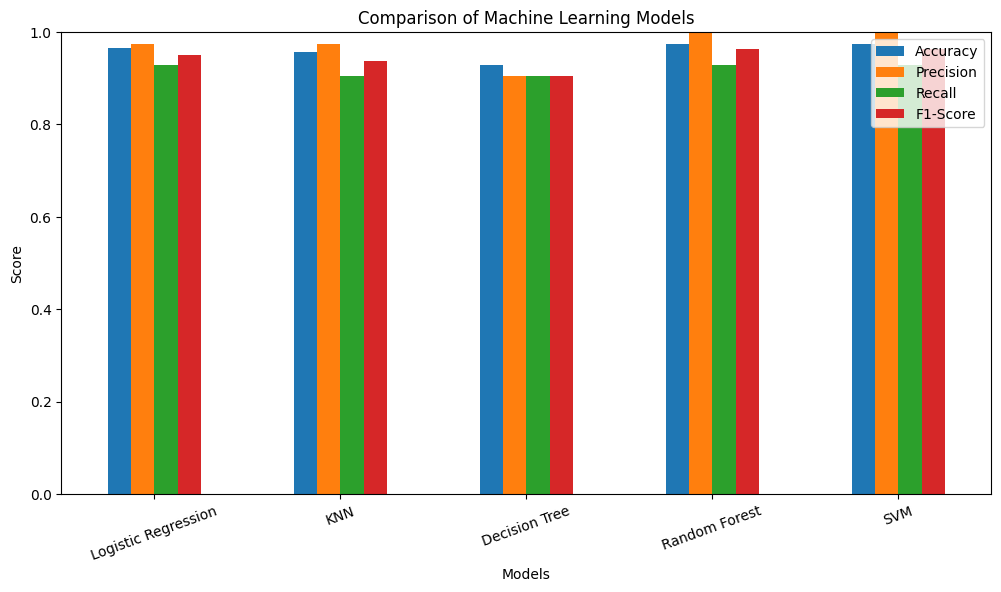

In [11]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

final_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.show()

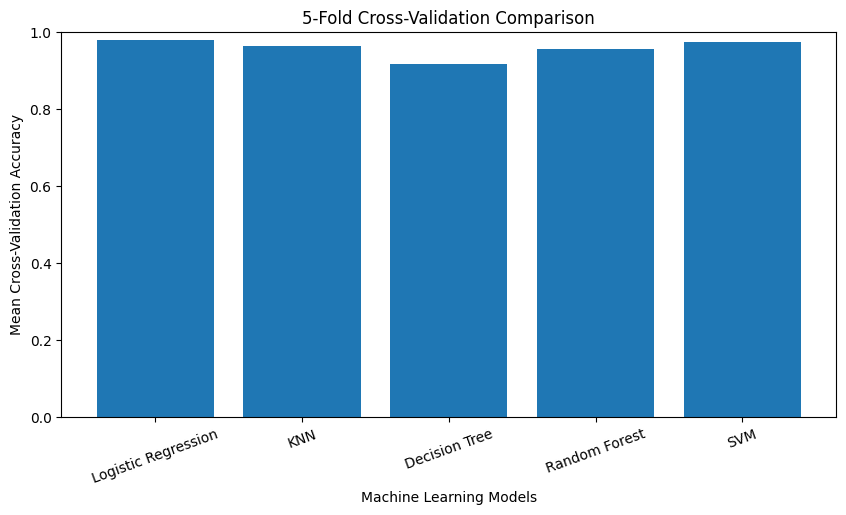

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    cv_df["Model"],
    cv_df["CV Mean Accuracy"]
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("5-Fold Cross-Validation Comparison")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [13]:
best_model = final_results.loc[
    final_results["F1-Score"].idxmax()
]

print("Recommended Model based on highest F1-Score:")
print(best_model["Model"])

print("\nPerformance:")
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1-Score:", best_model["F1-Score"])
print("CV Mean Accuracy:", best_model["CV Mean Accuracy"])

Recommended Model based on highest F1-Score:
Random Forest

Performance:
Accuracy: 0.9737
Precision: 1.0
Recall: 0.9286
F1-Score: 0.963
CV Mean Accuracy: 0.9560937742586555
